In [2]:
import numpy as np
import sys
import time
import yaml
import pickle


from pydrake.all import (
                         Hyperellipsoid,
                         RandomGenerator,
                         Point,
                         GurobiSolver,
                         MosekSolver,
                         MathematicalProgram)
from pydrake.geometry.optimization import (
    HPolyhedron,
    LoadIrisRegionsYamlFile,
    SaveIrisRegionsYamlFile,
    )
import pydrake.math as pm
import pydot
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42  # Use TrueType (Type 42) fonts
matplotlib.rcParams['ps.fonttype'] = 42  # Ensures consistency for PS output

In [12]:
experiment_name = "precise_parameters_initial"
# experiment_name = "precise_parameters_initial"
#experiment_name = "precise_parameters_fewer_zo_particles"

with open("logs/" + experiment_name + "/results.pkl", 'rb') as f:
    results = pickle.load(f)

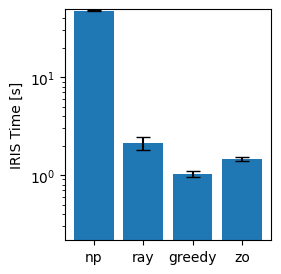

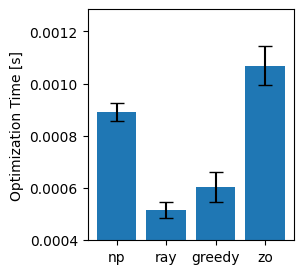

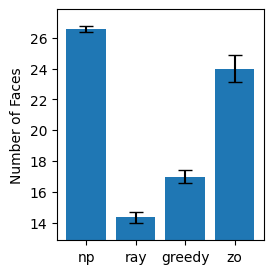

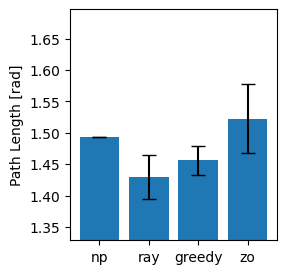

In [34]:
width = 4*2/3
# width = 4*2/3
height = 3
font_size = 13
axis_font_size = 11
linewidth = 2
labelpad = 5
markersizes=[5, 10]

labels = {'iris_times': "IRIS Time [s]",
          'optimizer_times': "Optimization Time [s]",
          'num_faces': "Number of Faces",
          'path_costs': "Path Length [rad]"}

for key in results.keys():
    if not key == "algs":
        plt.figure(figsize=(width, height))
        std = np.std(results[key], axis=1)
        plt.bar(results["algs"], np.mean(results[key], axis=1), yerr=std, capsize=5)
        plt.ylabel(labels[key])
        if key =='iris_times':
            ax = plt.gca()
            ax.set_yscale('log')
        y_min = np.min(results[key]) - np.max(std)
        y_max = np.max(results[key]) + np.max(std)
        padding = 0.001 * (y_max - y_min)  # 10% of the data range
        plt.ylim(y_min - padding, y_max + padding)


/tmp/ipykernel_747450/1185568556.py:42: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(y_min - padding, y_max + padding)


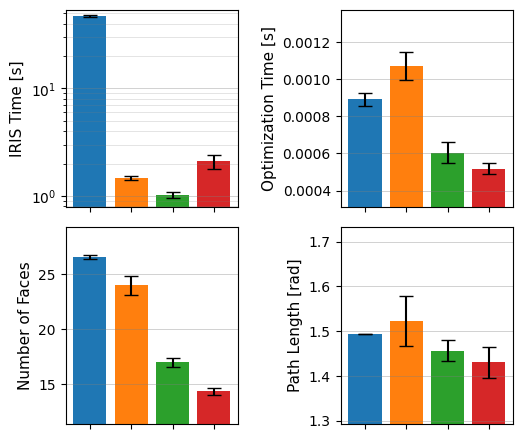

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Plot parameters
width = 4*2/3
height = 3
font_size = 13
axis_font_size = 11
linewidth = 2
labelpad = 5

# Labels for the metrics
labels = {'iris_times': "IRIS Time [s]",
          'optimizer_times': "Optimization Time [s]",
          'num_faces': "Number of Faces",
          'path_costs': "Path Length [rad]"}

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(width*2, height*1.5))
axes = axes.flatten()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
# Plot each metric
plot_idx = 0
for key in results.keys():
    if key != "algs":
        ax = axes[plot_idx]
        std = np.std(results[key], axis=1)[[0,3,2,1]]
        bars = ax.bar([results["algs"][i] for i in [0,3,2,1]], np.mean(results[key], axis=1)[[0,3,2,1]], 
                     yerr=std, capsize=5, linewidth=linewidth,
                     color=colors[:len(results["algs"])])
        
        ax.set_ylabel(labels[key], fontsize=axis_font_size)
        ax.tick_params(axis='both', which='major', labelsize=axis_font_size-1)
        # Remove x-axis labels
        ax.set_xticklabels([])
        if key == "iris_times":
            ax.set_yscale('log')
        # Set y-limits with padding
        y_min = np.min(results[key]) - np.max(std)
        y_max = np.max(results[key]) + np.max(std)
        padding = 0.1 * (y_max - y_min)  # 10% padding
        ax.set_ylim(y_min - padding, y_max + padding)
        
        # Rotate x-axis labels if needed
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        ax.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder = -10, axis="y")
        ax.grid(True, which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3, zorder = 0, axis="y")
        plot_idx += 1

# Adjust layout to prevent overlap
plt.tight_layout()

# Save as PDF for LaTeX (optional)
plt.savefig(f'motion_planning_experiment_precise.pdf', bbox_inches='tight', dpi=300)

plt.show()

In [10]:
std

array([0.0349377 , 0.02328908, 0.05574532])

In [13]:
results[key]

array([[1.79999948, 2.1205647 , 2.38086009, 2.1445291 , 1.60622931,
        2.16241121, 1.93119168, 1.95822477, 1.78791451, 2.06678987],
       [0.67171049, 0.6883812 , 0.76351285, 0.71402097, 0.68916273,
        0.72565579, 0.73435068, 0.6718173 , 0.66692615, 0.60920238],
       [2.58188725, 2.74304891, 2.61303973, 2.6621666 , 2.81183743,
        2.66485429, 2.60333157, 2.72274113, 2.75616789, 2.93477321]])

In [15]:
np. min(results[key])

0.6092023849487305